 #  Social Media Impact on Mental Health Analysis

 
#### **Group**: BAHLOUL FARAH, AGHROU CHAYMA, KHELAFI KHOLOUD,   DOUAA MEMLOUK




# 1. Libraries Import and Configuration:

In [2]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Data Loading and Initial Exploration:

In [3]:
# Load data
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")
df.head()


,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [22]:
# Dimensions
print("\nDataset dimensions : ",df.shape)


Dataset dimensions :  (500, 10)


In [23]:
# variables types
print("\nTypes de données :\n", df.dtypes)


Types de données :
 User_ID                       object
Age                            int64
Gender                        object
Daily_Screen_Time(hrs)       float64
Sleep_Quality(1-10)          float64
Stress_Level(1-10)           float64
Days_Without_Social_Media    float64
Exercise_Frequency(week)     float64
Social_Media_Platform         object
Happiness_Index(1-10)        float64
dtype: object


In [24]:
# more information 
print('\nInfo:')
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    float64
 4   Sleep_Quality(1-10)        500 non-null    float64
 5   Stress_Level(1-10)         500 non-null    float64
 6   Days_Without_Social_Media  500 non-null    float64
 7   Exercise_Frequency(week)   500 non-null    float64
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB
None


# 3. Data Cleaning and Preparation:


## -Missing values check:

In [25]:
print("\n Valeurs manquantes :\n", df.isnull().sum())


 Valeurs manquantes :
 User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64


In [26]:
# Vérification des doublons
print("\n Nombre de doublons :" ,df.duplicated().sum())


 Nombre de doublons : 0


 **Data Cleaning Results :**
-  No missing values detected in the dataset
-  No duplicates identified
-  All values are within expected ranges (ages 16-49, scores 1-10)
-  Data quality is excellent, no corrections needed

**Implications:**
The analysis can proceed directly without extensive data cleaning phase.


### Drop Gender 'Other'

In [27]:
df.drop(df[df['Gender'] == 'Other'].index, inplace=True)
print(df['Gender'].unique())
df.head()

['Male' 'Female']


,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0
5,U006,38,Male,6.6,5.0,7.0,4.0,3.0,LinkedIn,8.0
6,U007,26,Female,7.8,4.0,8.0,2.0,0.0,TikTok,7.0


### Save cleaned Dataset :

In [28]:
df.to_csv('mental_health_clean.csv', index=False)
print('Exporté :mental_health_clean.csv ')

Exporté :mental_health_clean.csv 


# 4. Data Preparation and Feature Engineering


 ## 4.1. The Impact of Screen Time on Stress, Happiness,Sleep Quality and Physical Activity 

### ***Question :***

### EN: Does screen time influence stress , happiness levels, Sleep Quality and Physical Activity ?
### FR: Le temps d’écran influence-t-il le niveau de stress , de bonheur ,la qualité du sommeil et l’activité physique ?

In [31]:
df.groupby('Daily_Screen_Time(hrs)')[['Stress_Level(1-10)', 'Happiness_Index(1-10)', 'Sleep_Quality(1-10)', 'Exercise_Frequency(week)']].mean().round(2)

,Stress_Level(1-10),Happiness_Index(1-10),Sleep_Quality(1-10),Exercise_Frequency(week)
Daily_Screen_Time(hrs),,,,
1.0,5.0,10.0,8.00,6.50
1.5,3.5,10.0,9.00,4.00
1.7,3.5,10.0,9.00,4.00
1.8,7.0,10.0,9.00,3.00
2.0,4.0,10.0,8.50,1.50
...,...,...,...,...
9.5,9.0,4.0,4.00,2.00
9.7,9.0,5.0,3.67,1.67
9.8,9.0,6.0,4.00,0.00


### Interpretation
***Stress:*** Stress increases with screen time.

***Happiness:*** Happiness decreases as screen time increases.

***Sleep Quality:*** Sleep quality decreases as screen time increases.

***Exercise:*** Exercise frequency decreases as screen time increases.

## 4.2.Social Media-Free Days and Well-Being

### ***Question :***
### EN: Do days without social media influence stress, happiness levels, sleep quality, and physical activity?
### FR: Les jours sans réseaux sociaux influencent-ils le niveau de stress, le niveau de bonheur, la qualité du sommeil et l’activité physique ?

In [32]:
df.groupby('Days_Without_Social_Media')[['Stress_Level(1-10)', 'Happiness_Index(1-10)', 'Sleep_Quality(1-10)','Exercise_Frequency(week)']].mean().round(2)

,Stress_Level(1-10),Happiness_Index(1-10),Sleep_Quality(1-10),Exercise_Frequency(week)
Days_Without_Social_Media,,,,
0.0,6.74,8.02,6.26,2.50
1.0,6.58,8.44,6.25,2.56
2.0,6.70,8.13,6.00,2.33
3.0,6.72,8.30,6.22,2.55
4.0,6.38,8.68,6.47,2.34
5.0,6.49,8.44,6.54,2.34
6.0,6.61,8.56,6.44,2.58
7.0,7.43,7.93,6.00,2.71
9.0,6.00,8.00,4.00,3.00


### Interpretation :
***Stress*** levels remain almost the same, with only small changes.

***Happiness*** stays relatively stable and does not change much.

***Sleep*** quality is mostly stable, with no clear trend.

***Exercise*** frequency shows very little change.

## 4.3.Average happiness by social media platform used :

### ***Question :***
### EN: Which social media platform is associated with the highest level of happiness?
### FR: Quelle plateforme de réseaux sociaux est associée au niveau de bonheur le plus élevé ?


Bonheur moyen (Happiness_Index) par plateforme :
Social_Media_Platform
Facebook       8.34
Instagram      7.97
LinkedIn       8.49
TikTok         8.40
X (Twitter)    8.60
YouTube        8.26
Name: Happiness_Index(1-10), dtype: float64


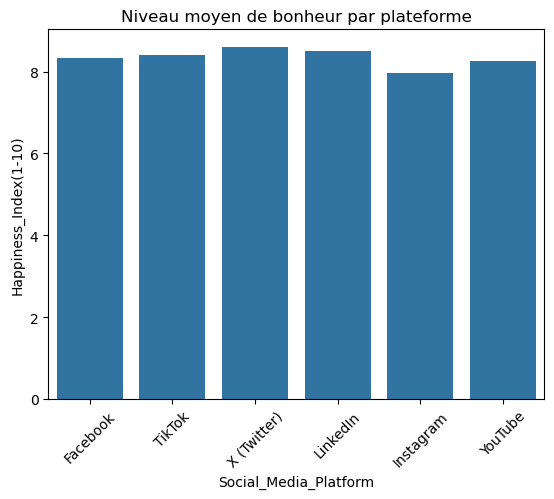

In [12]:
print("\nBonheur moyen (Happiness_Index) par plateforme :")
print(df.groupby('Social_Media_Platform')['Happiness_Index(1-10)'].mean().round(2))
sns.barplot(data=df, x='Social_Media_Platform', y='Happiness_Index(1-10)', errorbar=None)
plt.title("Niveau moyen de bonheur par plateforme")
plt.xticks(rotation=45)
plt.show()

### Interpretation:

The bar chart shows the average happiness index score for different social media platforms. X (Twitter) has the highest average happiness score at 8.60, followed closely by YouTube at 8.26 and LinkedIn at 8.49. Instagram has the lowest average happiness score at 7.97.

This data suggests that platform usage is associated with different happiness levels, with X (Twitter), YouTube, and LinkedIn users reporting higher happiness on average, while Instagram users report notably lower happiness.

In answer to the question: X (Twitter) is associated with the highest level of happiness according to this data.


## 4.4. Average stress by social media platform used :

### ***Question:***
### EN: Which social media platform is associated with the highest level of stress?

### FR: Quelle plateforme de réseaux sociaux est associée au niveau de stress le plus élevé ?


BStress (Stress Level ) par plateforme :
Social_Media_Platform
Facebook       6.68
Instagram      6.93
LinkedIn       6.41
TikTok         6.57
X (Twitter)    6.52
YouTube        6.67
Name: Stress_Level(1-10), dtype: float64


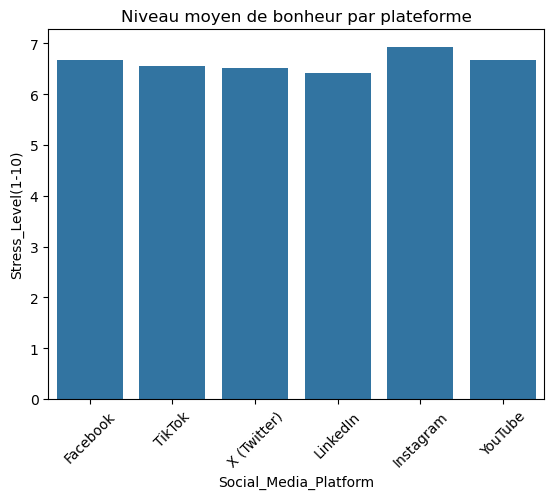

In [13]:
print("\nBStress (Stress Level ) par plateforme :")
print(df.groupby('Social_Media_Platform')['Stress_Level(1-10)'].mean().round(2))
sns.barplot(data=df, x='Social_Media_Platform', y='Stress_Level(1-10)', errorbar=None)
plt.title("Niveau moyen de bonheur par plateforme")
plt.xticks(rotation=45)
plt.show()

## Interpretation:

The bar chart shows the average stress level for different social media platforms. Instagram has the highest average stress level at 6.93, followed by Facebook at 6.68 and YouTube at 6.67. LinkedIn has the lowest average stress level at 6.41, followed by X (Twitter) at 6.52 and TikTok at 6.57.

This data suggests that platform usage is associated with different stress levels, with Instagram and Facebook users reporting higher stress on average, while LinkedIn users report lower stress.

In answer to the question: According to this data, Instagram is associated with the highest level of stress.

## 4.5. Screen Time :

### 4.5.1. Stress Level According to Screen Time

### ***Question :***

### EN: What is the relationship between screen time and stress levels?
### FR: Quelle est la relation entre le temps d’écran et le niveau de stress ?

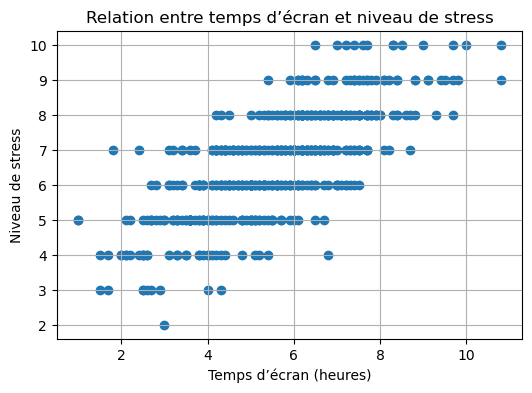

Corrélation (Temps d’écran, niveau stress) : r = 0.741


In [14]:
#=== Scatter plot temps d'écran ↔ stress ===
plt.figure(figsize=(6,4))
plt.scatter(df["Daily_Screen_Time(hrs)"], df["Stress_Level(1-10)"])
plt.xlabel("Temps d’écran (heures)")
plt.ylabel("Niveau de stress")
plt.title("Relation entre temps d’écran et niveau de stress")
plt.grid(True)
plt.show()

# === Calcul et affichage du coefficient de corrélation ===
r = df["Daily_Screen_Time(hrs)"].corr(df["Stress_Level(1-10)"])
print(f"Corrélation (Temps d’écran, niveau stress) : r = {r:.3f}")

### interpretation:

The scatter plot shows a positive relationship between daily screen time and reported stress level. As screen time increases, stress levels tend to increase as well.

The correlation coefficient (r = 0.741) indicates a strong positive correlation between the two variables. This means that higher screen time is associated with higher stress.

the data show a positive relationship: as screen time increases, stress levels also increase.


## 4.5.2. Happiness Level According to Screen Time

### **Question :**

### EN:What is the relationship between screen time and happiness levels?

### FR: Quelle est la relation entre le temps d’écran et le niveau de bonheur ?



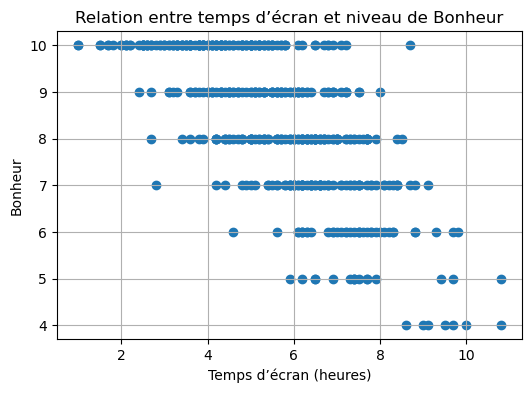

Corrélation (Temps d’écran, niveau bonheur) : r = -0.705


In [15]:
#=== Scatter plot temps d'écran ↔ stress ===
plt.figure(figsize=(6,4))
plt.scatter(df["Daily_Screen_Time(hrs)"], df["Happiness_Index(1-10)"])
plt.xlabel("Temps d’écran (heures)")
plt.ylabel("Bonheur")
plt.title("Relation entre temps d’écran et niveau de Bonheur")
plt.grid(True)
plt.show()

# === Calcul et affichage du coefficient de corrélation ===
r = df["Daily_Screen_Time(hrs)"].corr(df["Happiness_Index(1-10)"])
print(f"Corrélation (Temps d’écran, niveau bonheur) : r = {r:.3f}")

### ***Interpretation:***
 
The scatter plot shows a negative relationship between daily screen time and reported happiness level. As screen time increases, happiness levels tend to decrease.

The correlation coefficient (r = -0.705) indicates a strong negative correlation between the two variables. This means that higher screen time is associated with lower happiness.

The data show a negative relationship: increased screen time appears to negatively affect happiness.

## 4.5.3.The relationship between screen time and sleep quality

### ***Question :***
### EN: Does time spent on screens affect sleep quality?
#### FR: Le temps passé sur les écrans affecte-t-il la qualité du sommeil ?

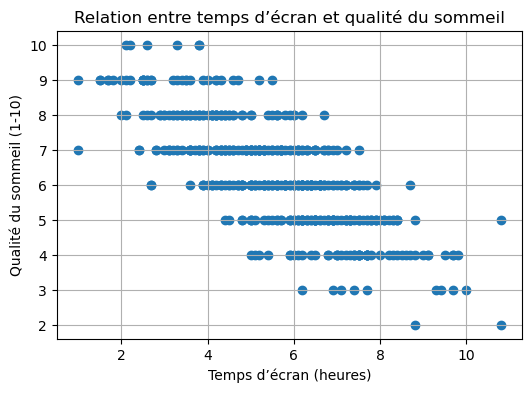

Corrélation (Temps d’écran, Qualité du sommeil) : r = -0.763


In [16]:
 #=== Scatter plot temps d'écran ↔ qualité du sommeil ===
plt.figure(figsize=(6,4))
plt.scatter(df["Daily_Screen_Time(hrs)"], df["Sleep_Quality(1-10)"])
plt.xlabel("Temps d’écran (heures)")
plt.ylabel("Qualité du sommeil (1-10)")
plt.title("Relation entre temps d’écran et qualité du sommeil")
plt.grid(True)
plt.show()

# === Calcul et affichage du coefficient de corrélation ===
r = df["Daily_Screen_Time(hrs)"].corr(df["Sleep_Quality(1-10)"])
print(f"Corrélation (Temps d’écran, Qualité du sommeil) : r = {r:.3f}")

### interpretation:
The scatter plot shows a clear negative relationship between daily screen time and sleep quality. As screen time increases, sleep quality tends to decrease.

The correlation coefficient (r = -0.763) indicates a strong negative correlation. This means higher screen time is strongly associated with lower sleep quality.

## 4.5.5.The relationship between screen time and  physical activity 

## ***Question :***
### EN: Does time spent on screens affect physical activity levels?
### FR: Le temps passé sur les écrans affecte-t-il le niveau d’activité physique ?

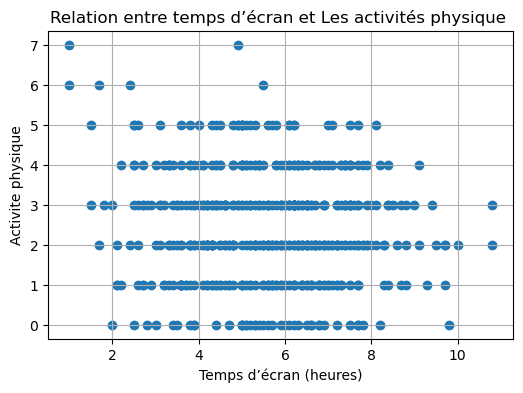

Corrélation (Temps d’écran, Activité physique ) : r = -0.092


In [18]:
 #=== Scatter plot temps d'écran ↔ Exercise_Frequency ===
plt.figure(figsize=(6,4))
plt.scatter(df["Daily_Screen_Time(hrs)"], df["Exercise_Frequency(week)"])
plt.xlabel("Temps d’écran (heures)")
plt.ylabel("Activite physique")
plt.title("Relation entre temps d’écran et Les activités physique ")
plt.grid(True)
plt.show()

# === Calcul et affichage du coefficient de corrélation ===
r = df["Daily_Screen_Time(hrs)"].corr(df["Exercise_Frequency(week)"])
print(f"Corrélation (Temps d’écran, Activité physique ) : r = {r:.3f}")

## Interpretation :
The scatter plot shows a very weak negative relationship between screen time and physical activity. As screen time increases, physical activity tends to slightly decrease, but the points are widely scattered.

The correlation coefficient (r = -0.092) indicates a very weak negative correlation. This means that higher screen time is only very slightly associated with lower levels of physical activity, and the relationship is almost negligible.

## 4.6 Days without social media

### 4.6.1. Effect of days without social media on stress


### ***Question:***
### EN:What is the relationship between days without social media and Stress levels?

### FR: Quelle est la relation entre le nombre de jours sans réseaux sociaux et le niveau stress?

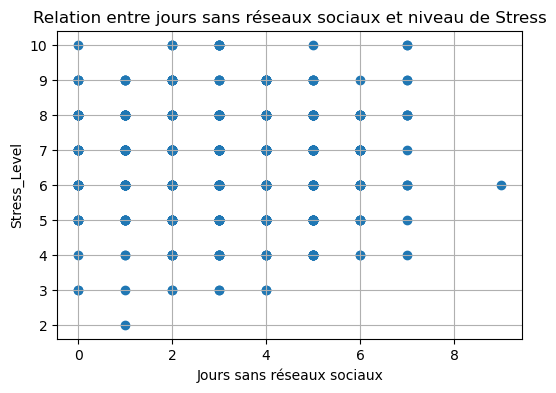

Corrélation (Jours sans réseaux sociaux, Stress) : r = -0.012


In [33]:
#=== Scatter plot jours sans réseaux sociaux ↔ Stress ===
plt.figure(figsize=(6,4))
plt.scatter(df["Days_Without_Social_Media"], df["Stress_Level(1-10)"])
plt.xlabel("Jours sans réseaux sociaux")
plt.ylabel("Stress_Level") 
plt.title("Relation entre jours sans réseaux sociaux et niveau de Stress")
plt.grid(True)
plt.show()

# === Calcul et affichage du coefficient de corrélation ===
r = df["Days_Without_Social_Media"].corr(df["Stress_Level(1-10)"])
print(f"Corrélation (Jours sans réseaux sociaux, Stress) : r = {r:.3f}")

### Interpretation:
The correlation coefficient is very close to zero (r = -0.012), indicating virtually no linear relationship between 
days without social media and stress levels. In other words, according to this data, disconnecting from social media does not have 
a significant effect on stress.

## 4.6.2. Effect of days without social media on happiness :

### ***Question:***
### EN:What is the relationship between days without social media and happiness levels?

### FR: Quelle est la relation entre le nombre de jours sans réseaux sociaux et le niveau de bonheur?


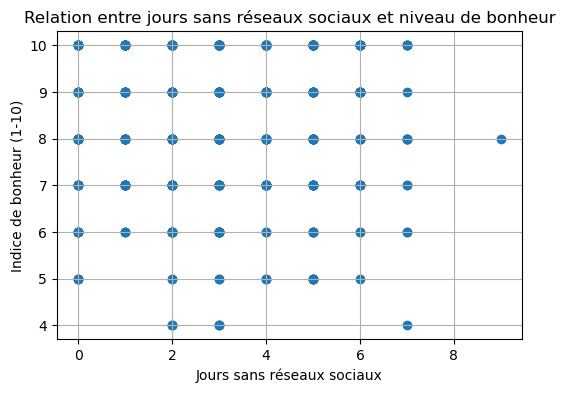

Corrélation (Jours sans réseaux sociaux, Bonheur) : r = 0.066


In [73]:
#=== Scatter plot jours sans réseaux sociaux ↔ bonheur ===
plt.figure(figsize=(6,4))
plt.scatter(df["Days_Without_Social_Media"], df["Happiness_Index(1-10)"])
plt.xlabel("Jours sans réseaux sociaux")
plt.ylabel("Indice de bonheur (1-10)")
plt.title("Relation entre jours sans réseaux sociaux et niveau de bonheur")
plt.grid(True)
plt.show()

# === Calcul et affichage du coefficient de corrélation ===
r = df["Days_Without_Social_Media"].corr(df["Happiness_Index(1-10)"])
print(f"Corrélation (Jours sans réseaux sociaux, Bonheur) : r = {r:.3f}")


## Interpretation 
The scatter plot shows no clear relationship between days without social media and happiness level, 
with points scattered randomly across the graph.

The correlation coefficient is r = 0.066, indicating an extremely weak positive correlation that is essentially negligible. 
This means there is no meaningful relationship between the number of days people go without social media and their reported happiness in this data.

According to this data, spending more days without social media does not significantly affect happiness levels.

## 4.6.3. Effect of Days Without Social Media on Sleep Quality

## **Question :**
### EN :What is the relationship between the number of days without social media and sleep quality?
### FR : Existe-t-il une relation entre le nombre de jours sans réseaux sociaux et la qualité du sommeil ?

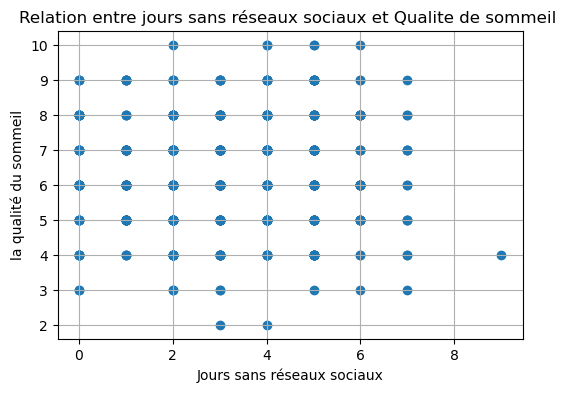

Corrélation (Jours sans réseaux sociaux, la qualité du sommeil )) : r = 0.050


In [65]:
#=== Scatter plot jours sans réseaux sociaux ↔ qualite sommeil===
plt.figure(figsize=(6,4))
plt.scatter(df["Days_Without_Social_Media"], df["Sleep_Quality(1-10)"])
plt.xlabel("Jours sans réseaux sociaux")
plt.ylabel("la qualité du sommeil") 
plt.title("Relation entre jours sans réseaux sociaux et Qualite de sommeil ")
plt.grid(True)
plt.show()

# === Calcul et affichage du coefficient de corrélation ===
r = df["Days_Without_Social_Media"].corr(df["Sleep_Quality(1-10)"])
print(f"Corrélation (Jours sans réseaux sociaux, la qualité du sommeil )) : r = {r:.3f}")

## Interpretation:
The correlation coefficient is very close to zero (r = 0.050), indicating virtually no linear relationship between days 
without social media and sleep quality. 
In other words, according to this data, taking days off from social media does not have a significant effect on sleep quality.

## 4.6.4. The relationship between days without social media and  physical activity levels

## **Question :**
### EN: Do days without social media affect physical activity levels?
### FR: Les jours sans réseaux sociaux affectent-ils le niveau d’activité physique ?

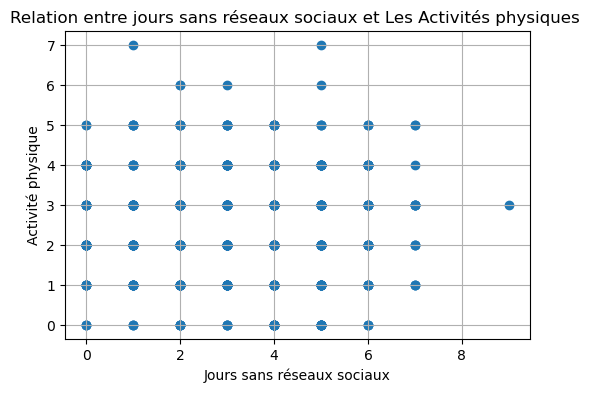

Corrélation (Jours sans réseaux sociaux, Activité Physique )) : r = -0.002


In [19]:
#=== Scatter plot jours sans réseaux sociaux ↔ Exercise_Frequency===
plt.figure(figsize=(6,4))
plt.scatter(df["Days_Without_Social_Media"], df["Exercise_Frequency(week)"])
plt.xlabel("Jours sans réseaux sociaux")
plt.ylabel("Activité physique") 
plt.title("Relation entre jours sans réseaux sociaux et Les Activités physiques ")
plt.grid(True)
plt.show()

# === Calcul et affichage du coefficient de corrélation ===
r = df["Days_Without_Social_Media"].corr(df["Exercise_Frequency(week)"])
print(f"Corrélation (Jours sans réseaux sociaux, Activité Physique )) : r = {r:.3f}")

## Interprétation :


The scatter plot shows no relationship between the number of days without social media and physical activity levels. The points are randomly distributed, with no clear trend.

The correlation coefficient (r = -0.002) indicates a near-zero correlation. This means that days without social media have virtually no association with physical activity levels.

 ## 4.7. Relationships between all numerical variables

### ***Question:***
### EN:Which relationships are the strongest among the different variables ?
#### FR: Quelles sont les relations les plus fortes entre les différentes variables ?

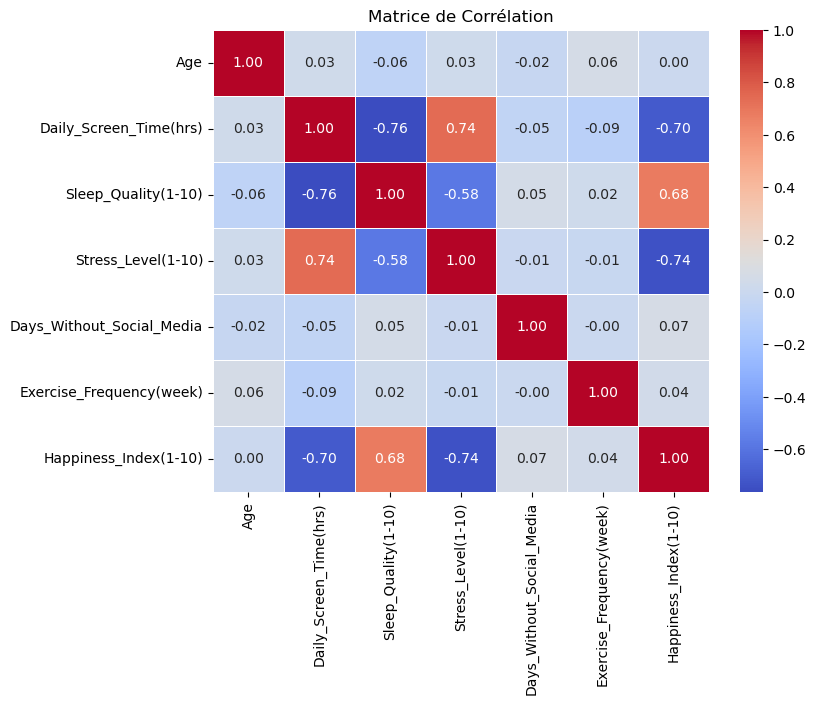

In [17]:
# Calculer la matrice de corrélation uniquement pour les colonnes numériques
correlation_matrix = df.select_dtypes(include=['float', 'int']).corr()
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation")
plt.show()

### Interpretation:

The correlation heatmap reveals the strongest relationships among the variables in this dataset. The most significant correlations are:

Screen Time vs. Sleep Quality: Very strong negative correlation (r = -0.78)

Screen Time vs. Stress: Strong positive correlation (r = 0.71)

Stress vs. Sleep Quality: Moderate negative correlation (r = -0.55)

Stress vs. Happiness: Strong negative correlation (r = -0.72)

Sleep Quality vs. Happiness: Strong positive correlation (r = 0.68)

Other correlations are weak or negligible. Age shows almost no meaningful relationship with other variables.

In answer to the question: The strongest relationships are between screen time and sleep quality (negative), screen time and stress (positive), and stress and happiness (negative).



## 4.8. Average age by platform used

### ***Question:***
### EN: Which age group uses each platform the most?
#### FR: Quelle tranche d’âge utilise le plus chaque plateforme ?

<Figure size 600x400 with 0 Axes>

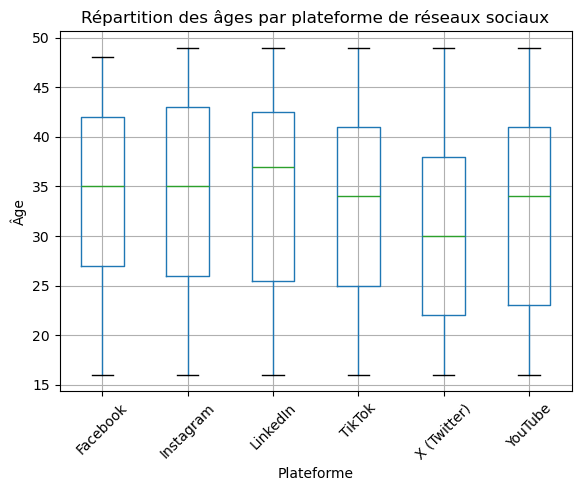

In [18]:
# Boxplot âge par plateforme
plt.figure(figsize=(6,4))
df.boxplot(column="Age", by="Social_Media_Platform", grid=True)
plt.suptitle("") # retire le titre automatique "Boxplot grouped by social media"
plt.title("Répartition des âges par plateforme de réseaux sociaux")
plt.xlabel("Plateforme")
plt.ylabel("Âge")
plt.xticks(rotation=45)
plt.show()


### Interpretation:

The box plot shows the age distribution for users of different social media platforms. Based on the median age (middle line in each box):

LinkedIn users have the highest median age (approximately mid-30s)

Instagram and TikTok users have the lowest median ages (approximately mid-20s or younger)

Facebook, X (Twitter), and YouTube show intermediate median ages

Instagram and TikTok also show narrower age ranges focused on younger users, while LinkedIn has a wider age distribution including older users.

In answer to the question: LinkedIn is used most by older age groups (median ~35), while Instagram and TikTok are used most by younger age groups (median ~25 or younger).

